In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

batch_size = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
    '/Users/kpvarma/PycharmProjects/Chest_X_Rays_Pnemonia_3/Data_Augmentation/dataset/train',
    target_size=(150, 150),
    batch_size=batch_size,
    class_mode='binary'
)

validation_generator = test_datagen.flow_from_directory(
    '/Users/kpvarma/PycharmProjects/Chest_X_Rays_Pnemonia_3/Data_Augmentation/dataset/test',
    target_size=(150, 150),
    batch_size=batch_size,
    class_mode='binary'
)



Found 800 images belonging to 2 classes.
Found 200 images belonging to 2 classes.


In [6]:
print(train_generator.class_indices)


{'train_cat': 0, 'train_dog': 1}


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Activation, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [11]:
model=Sequential()
model.add(Conv2D(32,(3,3),input_shape=(150,150,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(32,(3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64,(3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

In [12]:
model.add(Flatten())
model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(1))
model.add(Activation('sigmoid'))
model.compile(loss='binary_crossentropy',optimizer='rmsprop',metrics=['accuracy'])

In [15]:
history = model.fit(
    train_generator,
    steps_per_epoch=800 // batch_size,
    epochs=25,
    validation_data=validation_generator,
    validation_steps=200 // batch_size
)


Epoch 1/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 145ms/step - accuracy: 0.5763 - loss: 0.7029 - val_accuracy: 0.7917 - val_loss: 0.5530
Epoch 2/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 139ms/step - accuracy: 0.7663 - loss: 0.5031 - val_accuracy: 0.8385 - val_loss: 0.3799
Epoch 3/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - accuracy: 0.8275 - loss: 0.4165 - val_accuracy: 0.8490 - val_loss: 0.3229
Epoch 4/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 156ms/step - accuracy: 0.8650 - loss: 0.3285 - val_accuracy: 0.9115 - val_loss: 0.2201
Epoch 5/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 152ms/step - accuracy: 0.9125 - loss: 0.2488 - val_accuracy: 0.9323 - val_loss: 0.2182
Epoch 6/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 148ms/step - accuracy: 0.9175 - loss: 0.2256 - val_accuracy: 0.9479 - val_loss: 0.1669
Epoch 7/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 138ms/step - accuracy: 0.9400 - loss: 0.1776 - val_accuracy: 0.9531 - val_loss: 0.1843
Epoch 8/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 143ms/step - accuracy: 0.9388 - loss: 0.1759 - val_accuracy: 0.

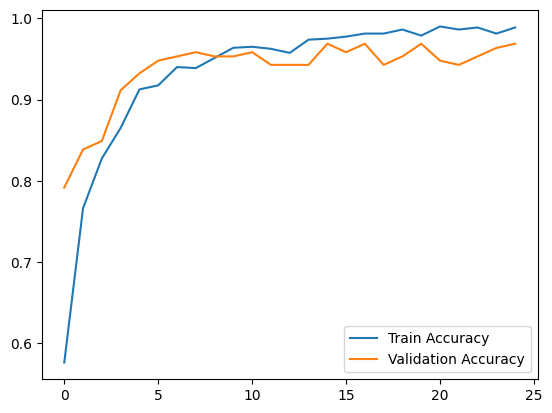

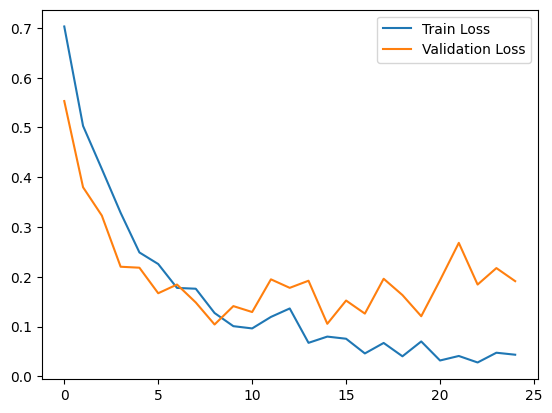

In [16]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()
